# Home work 1C

In [1]:
#@title #Import packages that are required
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
#@title ##Ricker wavelet function

def Ricker(f0,t0,t):
  mu = (np.pi**2)*(f0**2)*((t-t0)**2)
  return (1-2*mu)*np.exp(-mu)



[0]
49.5
500


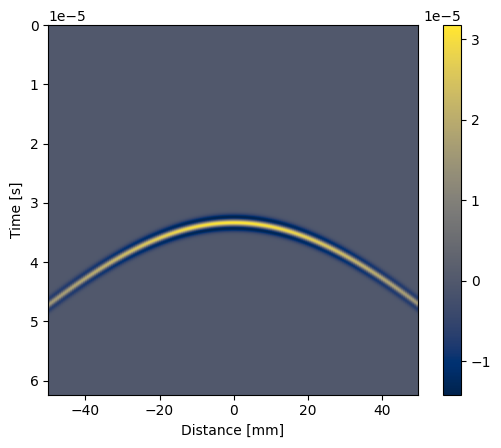

In [3]:
# @title #Ultrasonic wavefield of a point source

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=25m and center is x=0

sourceMin = 0
sourceMax = 0
dSource = 1
sourceAxis=np.arange(sourceMin, sourceMax+dSource, dSource)
print(sourceAxis)
xmin=-50 # millimeter
xmax = 49.5 # millimeter
dx=0.5
xaxis=np.arange(xmin, xmax+dx, dx)
nx = len(xaxis)
xmax = xaxis[-1]
print(xmax)

f0 = 0.4e6 # Hz
v = 1.5e6 # mm/s = 1500 m/s
tmin = 0
dt = 0.125e-6 # .125 microsecond
nt = 500

taxis = tmin+np.arange(nt)*dt
tmax = taxis[-1]
print(len(taxis))
z = 50 # mm
z2 = z*z
data=np.zeros((nx,nt))

for source in sourceAxis:
    for ix in range(nx):
        distance = math.sqrt(pow(xaxis[ix]-source,2)+z2)
        delay = distance/v
        amplitude = 1/(4*np.pi*pow(distance,2))
        for it in range(nt):
            data[ix,it]+=amplitude * Ricker(f0,0,taxis[it]-delay)

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect = (-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [mm]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(200, 500)
(200, 251)


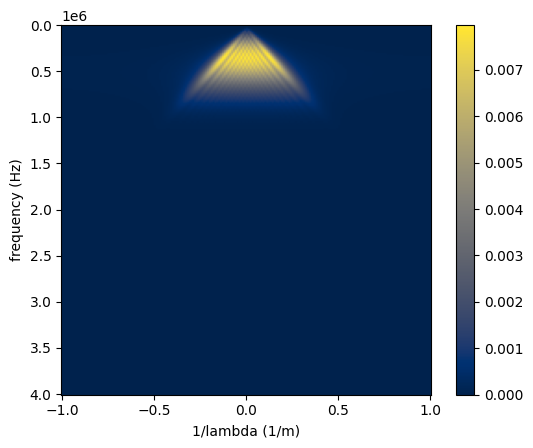

In [4]:
# @title Fourier transform of an ultrasound wave
# Example to make the FK plot of the 2D array
# Note the following:
# - we use rfft2 to do first a real-complex over time and regular FFT over x
# - we plot again the transposed to make frequency axis downward
# - we apply fftshft with axes=1 to put kx=0 in the middle
# - we flip over the kx-axis, because in our definition FFT over x has + sign in the forward transform

# Note that with this case of a horizontal event, we only expect contrbution at kx=0
print(data.shape)
FK=np.fft.rfft2(data)
print(FK.shape)
plt.figure()
plt.imshow(((np.abs(np.fft.fftshift(FK.T,axes=1))))
           ,cmap='cividis'
  ,extent=[-nx/2/(-xmin+xmax),+nx/2/(-xmin+xmax),nt/2/(-tmin+tmax),0]
          , aspect = 0.8*(-tmin+tmax)/(-xmin+xmax))
plt.xlabel("1/lambda (1/m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()
# Note: the Fourier transform was performed on a matrix.
# scaling was added by the parameter "extent"

[-8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8]
49.5
500


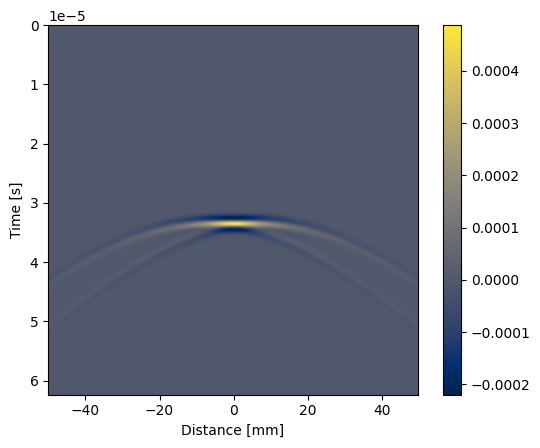

In [5]:
# @title #Ultrasonic wavefield of a small source array

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=25m and center is x=0

sourceMin = -8
sourceMax = 8
dSource = 1
sourceAxis=np.arange(sourceMin, sourceMax+dSource, dSource)
print(sourceAxis)
xmin=-50 # millimeter
xmax = 49.5 # millimeter
dx=0.5
xaxis=np.arange(xmin, xmax+dx, dx)
nx = len(xaxis)
xmax = xaxis[-1]
print(xmax)

f0 = 0.4e6 # Hz
v = 1.5e6 # mm/s = 1500 m/s
tmin = 0
dt = 0.125e-6 # .125 microsecond
nt = 500

taxis = tmin+np.arange(nt)*dt
tmax = taxis[-1]
print(len(taxis))
z = 50 # mm
z2 = z*z
data=np.zeros((nx,nt))

for source in sourceAxis:
    for ix in range(nx):
        distance = math.sqrt(pow(xaxis[ix]-source,2)+z2)
        delay = distance/v
        amplitude = 1/(4*np.pi*pow(distance,2))
        for it in range(nt):
            data[ix,it]+=amplitude * Ricker(f0,0,taxis[it]-delay)

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect = (-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [mm]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(200, 500)
(200, 251)


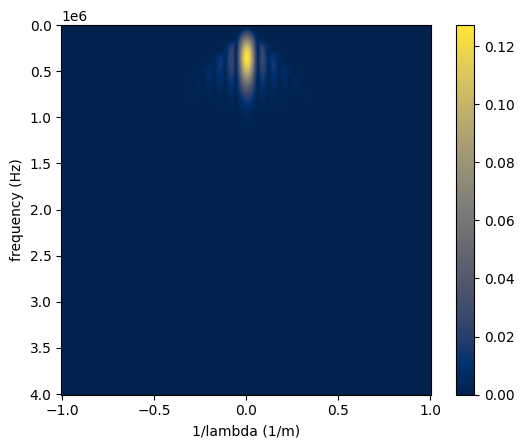

In [6]:
# @title Fourier transform of an ultrasound wave
# Example to make the FK plot of the 2D array
# Note the following:
# - we use rfft2 to do first a real-complex over time and regular FFT over x
# - we plot again the transposed to make frequency axis downward
# - we apply fftshft with axes=1 to put kx=0 in the middle
# - we flip over the kx-axis, because in our definition FFT over x has + sign in the forward transform

# Note that with this case of a horizontal event, we only expect contrbution at kx=0
print(data.shape)
FK=np.fft.rfft2(data)
print(FK.shape)
plt.figure()
plt.imshow(((np.abs(np.fft.fftshift(FK.T,axes=1))))
           ,cmap='cividis'
  ,extent=[-nx/2/(-xmin+xmax),+nx/2/(-xmin+xmax),nt/2/(-tmin+tmax),0]
          , aspect = 0.8*(-tmin+tmax)/(-xmin+xmax))
plt.xlabel("1/lambda (1/m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()
# Note: the Fourier transform was performed on a matrix.
# scaling was added by the parameter "extent"